In [1]:
import os
import tempfile
from typing import Tuple, List, Dict

import numpy as np
from PIL import Image
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [2]:
def read_image_as_array(path: str) -> np.ndarray:
    """
    Đọc ảnh từ đường dẫn và trả về mảng numpy (H, W, 3).

    - Kiểm tra file có tồn tại không.
    - Mở ảnh bằng Pillow.
    - Chuẩn hóa về RGB (3 kênh màu).
    - Chuyển sang numpy array để các thuật toán ML xử lý.
    """
    if not os.path.exists(path):
        raise FileNotFoundError(f"File không tồn tại: {path}")
    
    try:
        img = Image.open(path)
        # Chuẩn hóa về RGB để đảm bảo shape (H, W, 3)
        if img.mode != 'RGB':
            img = img.convert('RGB')
        arr = np.array(img)
        return arr
    except Exception as e:
        raise ValueError(f"Không thể đọc ảnh: {e}")

In [3]:
# %% HÀM K-MEANS COLOR QUANTIZATION

def quantize_image_kmeans(image_array: np.ndarray, k: int) -> Tuple[np.ndarray, np.ndarray]:
    """
    Giảm số màu của ảnh về K màu bằng K-means clustering.

    - Reshape ảnh (H, W, 3) thành (N, 3), mỗi pixel là 1 điểm dữ liệu (R,G,B).
    - Áp dụng K-means để chia thành K cụm màu.
    - Mỗi cụm có một centroid (màu đại diện).
    - Thay mỗi pixel bằng centroid của cụm tương ứng.

    Returns:
        quantized_image: ảnh đã quantize, shape (H, W, 3)
        palette: mảng (K, 3) - các màu centroid (palette)
    """
    h, w, c = image_array.shape
    pixels = image_array.reshape(-1, 3)

    # n_init='auto' để tránh warning ở sklearn mới
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(pixels)

    labels = kmeans.labels_          # nhãn cụm cho từng pixel
    palette = kmeans.cluster_centers_.astype(np.uint8)  # K màu đại diện

    # Thay pixel bằng màu trung tâm cụm
    quantized_pixels = palette[labels]
    quantized_image = quantized_pixels.reshape(h, w, c)

    return quantized_image, palette

In [4]:
# %% HÀM LƯU PNG-8 (INDEXED COLOR)

def save_indexed_png_from_array(image_array: np.ndarray, path: str, k: int) -> None:
    """
    Lưu mảng RGB thành ảnh PNG-8 với tối đa K màu.

    PNG-8 dùng indexed color (mode 'P'):
    - Mỗi pixel chỉ lưu 1 byte index → trỏ đến bảng màu (palette).
    - Giảm dung lượng so với PNG-24 (true color).
    """
    img_pil = Image.fromarray(image_array.astype(np.uint8))

    # Convert sang palette mode với tối đa K màu
    img_pil = img_pil.convert("P", palette=Image.Palette.ADAPTIVE, colors=k)

    # optimize=True để nén tốt hơn
    img_pil.save(path, optimize=True)


def get_file_size_kb(path: str) -> float:
    """Trả về dung lượng file (KB)."""
    size_bytes = os.path.getsize(path)
    return size_bytes / 1024.0


In [ ]:
def find_optimal_k(image_array: np.ndarray, target_kb: float,
                   min_k: int = 2, max_k: int = 256,
                   max_iterations: int = 20) -> Tuple[int, float, List[Dict]]:
   
    best_k = min_k
    best_size = float('inf')
    best_diff = float('inf')
    history: List[Dict] = []

    print(f"🔍 Đang tìm K tối ưu (target: {target_kb:.2f} KB)...")

    with tempfile.TemporaryDirectory() as tmpdir:
        iteration = 0
        lo, hi = min_k, max_k

        # Binary search trong khoảng [lo, hi]
        while hi - lo > 2 and iteration < max_iterations:
            iteration += 1
            mid_k = (lo + hi) // 2

            quantized, _ = quantize_image_kmeans(image_array, mid_k)
            temp_path = os.path.join(tmpdir, f"temp_{mid_k}.png")
            save_indexed_png_from_array(quantized, temp_path, mid_k)

            size_kb = get_file_size_kb(temp_path)
            diff = abs(size_kb - target_kb)

            print(f"  Thử K={mid_k:3d} → {size_kb:7.2f} KB (diff: {diff:.2f} KB)")

            history.append({"k": mid_k, "size_kb": size_kb, "diff": diff})

            if diff < best_diff:
                best_diff = diff
                best_k = mid_k
                best_size = size_kb

            # Điều chỉnh khoảng binary search
            if size_kb > target_kb:
                hi = mid_k - 1  # dung lượng lớn quá → giảm K
            else:
                lo = mid_k + 1  # dung lượng còn nhỏ → thử tăng K

        # Thử thêm các K trong khoảng [lo, hi] để chắc chắn
        for k in range(lo, hi + 1):
            if k < min_k or k > max_k:
                continue
            quantized, _ = quantize_image_kmeans(image_array, k)
            temp_path = os.path.join(tmpdir, f"temp_{k}.png")
            save_indexed_png_from_array(quantized, temp_path, k)

            size_kb = get_file_size_kb(temp_path)
            diff = abs(size_kb - target_kb)
            print(f"  Thử K={k:3d} → {size_kb:7.2f} KB (diff: {diff:.2f} KB)")

            history.append({"k": k, "size_kb": size_kb, "diff": diff})

            if diff < best_diff:
                best_diff = diff
                best_k = k
                best_size = size_kb

    return best_k, best_size, history

In [6]:
# %% CÁC HÀM VẼ / VISUALIZATION

def show_original_image(image_array: np.ndarray) -> None:
    """Hiển thị ảnh gốc."""
    plt.figure(figsize=(5, 5))
    plt.imshow(image_array)
    plt.title("Ảnh gốc (Original)")
    plt.axis("off")
    plt.tight_layout()
    plt.show()


def show_quantized_grid(image_array: np.ndarray, k_list: List[int]) -> None:
    """
    Hiển thị ảnh quantize với nhiều K khác nhau trên một grid.
    Giúp trực quan:
    - K nhỏ → ảnh bị posterize mạnh, ít màu.
    - K lớn → ảnh mượt hơn, gần gốc hơn.
    """
    n = len(k_list)
    cols = min(n, 4)
    rows = (n + cols - 1) // cols

    plt.figure(figsize=(4 * cols, 4 * rows))

    for i, k in enumerate(k_list, start=1):
        quantized, _ = quantize_image_kmeans(image_array, k)
        plt.subplot(rows, cols, i)
        plt.imshow(quantized)
        plt.title(f"K = {k}")
        plt.axis("off")

    plt.suptitle("So sánh ảnh với các giá trị K khác nhau", fontsize=14)
    plt.tight_layout()
    plt.show()


def show_palette(palette: np.ndarray, k: int) -> None:
    """
    Vẽ bảng màu (palette) thu được từ K-means.
    Mỗi ô là một centroid (màu đại diện).
    """
    # palette: shape (K, 3)
    # Tạo ảnh nhỏ (K x 1) rồi phóng to
    swatch = np.zeros((50, 50 * k, 3), dtype=np.uint8)
    for i, color in enumerate(palette):
        swatch[:, i * 50:(i + 1) * 50, :] = color

    plt.figure(figsize=(min(12, k * 1.2), 2))
    plt.imshow(swatch)
    plt.title(f"Palette {k} màu (centroid từ K-means)")
    plt.axis("off")
    plt.tight_layout()
    plt.show()


def plot_k_vs_size(history: List[Dict], target_kb: float) -> None:
    """
    Vẽ biểu đồ K vs dung lượng (KB) dựa trên history.
    Cho thấy:
    - Khi K tăng, dung lượng tăng.
    - Tại sao dùng binary search hợp lý.
    """
    if not history:
        print("⚠️ Không có history để vẽ.")
        return

    history_sorted = sorted(history, key=lambda x: x["k"])
    ks = [h["k"] for h in history_sorted]
    sizes = [h["size_kb"] for h in history_sorted]

    plt.figure(figsize=(7, 5))
    plt.plot(ks, sizes, marker="o")
    plt.axhline(target_kb, linestyle="--", label=f"Target {target_kb:.1f} KB")
    plt.xlabel("K (số màu)")
    plt.ylabel("Dung lượng (KB)")
    plt.title("Quan hệ giữa số màu K và dung lượng ảnh")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


def show_comparison(original_array: np.ndarray,
                    quantized_array: np.ndarray,
                    original_size: float,
                    final_size: float,
                    k: int) -> None:
    """
    Hiển thị ảnh gốc và ảnh sau nén cạnh nhau để so sánh trực quan.
    """
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(original_array)
    plt.title(f"Ảnh gốc\n{original_size:.2f} KB")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(quantized_array)
    plt.title(f"Ảnh sau nén (K={k})\n{final_size:.2f} KB")
    plt.axis("off")

    plt.suptitle("So sánh ảnh gốc và ảnh sau nén bằng Color Quantization", fontsize=14)
    plt.tight_layout()
    plt.show()

In [7]:


# %% DEMO CHÍNH

def demo_pipeline(input_path: str, target_kb: float) -> None:
    """
    Chạy toàn bộ pipeline:
    - Đọc ảnh
    - Hiển thị ảnh gốc
    - Thử một vài K cố định để minh họa
    - Tìm K tối ưu theo target KB (binary search)
    - Hiển thị palette & biểu đồ K vs size
    - Hiển thị so sánh ảnh gốc vs ảnh sau nén
    """
    print(f"📂 Đọc ảnh từ: {input_path}")
    image_array = read_image_as_array(input_path)

    # Hiển thị ảnh gốc
    show_original_image(image_array)

    # Tính dung lượng ảnh gốc (lưu tạm dưới dạng PNG để so sánh công bằng)
    with tempfile.NamedTemporaryFile(suffix='.png', delete=False) as tmp:
        tmp_path = tmp.name
        Image.fromarray(image_array).save(tmp_path)
        original_size = get_file_size_kb(tmp_path)
    os.unlink(tmp_path)

    print(f"📊 Dung lượng ảnh gốc (PNG-24): {original_size:.2f} KB")
    print(f"🎯 Target dung lượng: {target_kb:.2f} KB\n")

    # 1) Minh họa cơ bản: thử trước vài K cố định
    k_demo = [4, 8, 16, 32, 64]
    print("🧪 Minh họa ảnh với các K cố định:", k_demo)
    show_quantized_grid(image_array, k_demo)

    # 2) Chạy K-means với một K (ví dụ 16) để show palette
    k_palette = 16
    print(f"🎨 Xây dựng palette với K={k_palette} để minh họa")
    quantized_for_palette, palette = quantize_image_kmeans(image_array, k_palette)
    show_palette(palette, k_palette)

    # 3) Tìm K tối ưu theo target dung lượng
    optimal_k, final_size_estimate, history = find_optimal_k(
        image_array, target_kb, min_k=2, max_k=256
    )

    print("\n✅ K tối ưu tìm được (ước lượng):", optimal_k)
    print(f"   Dung lượng ước lượng gần target: {final_size_estimate:.2f} KB\n")

    # 4) Vẽ biểu đồ K vs dung lượng (dựa trên history)
    plot_k_vs_size(history, target_kb)

    # 5) Tạo ảnh cuối cùng với K tối ưu & lưu ra file
    print(f"🖼️ Tạo ảnh cuối cùng với K={optimal_k} và lưu file...")
    final_quantized, _ = quantize_image_kmeans(image_array, optimal_k)

    output_path = "output_quantized.png"
    save_indexed_png_from_array(final_quantized, output_path, optimal_k)
    actual_size = get_file_size_kb(output_path)

    print(f"💾 Ảnh sau nén lưu tại: {output_path}")
    print(f"📉 Dung lượng ảnh sau nén (PNG-8): {actual_size:.2f} KB")

    compression_ratio = (1 - actual_size / original_size) * 100
    print(f"⚖️ Tỷ lệ nén: {compression_ratio:.1f}% so với ảnh gốc\n")

    # 6) So sánh ảnh gốc và ảnh sau nén
    show_comparison(image_array, final_quantized, original_size, actual_size, optimal_k)

📂 Đọc ảnh từ: input.png


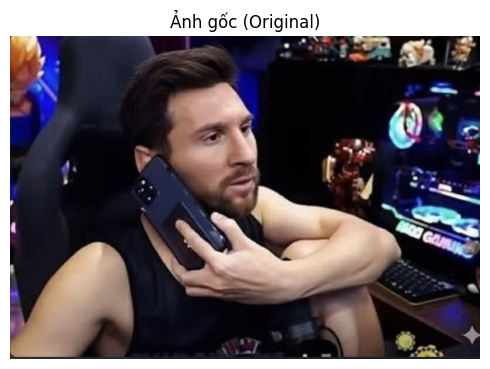

📊 Dung lượng ảnh gốc (PNG-24): 2276.39 KB
🎯 Target dung lượng: 50.00 KB

🧪 Minh họa ảnh với các K cố định: [4, 8, 16, 32, 64]


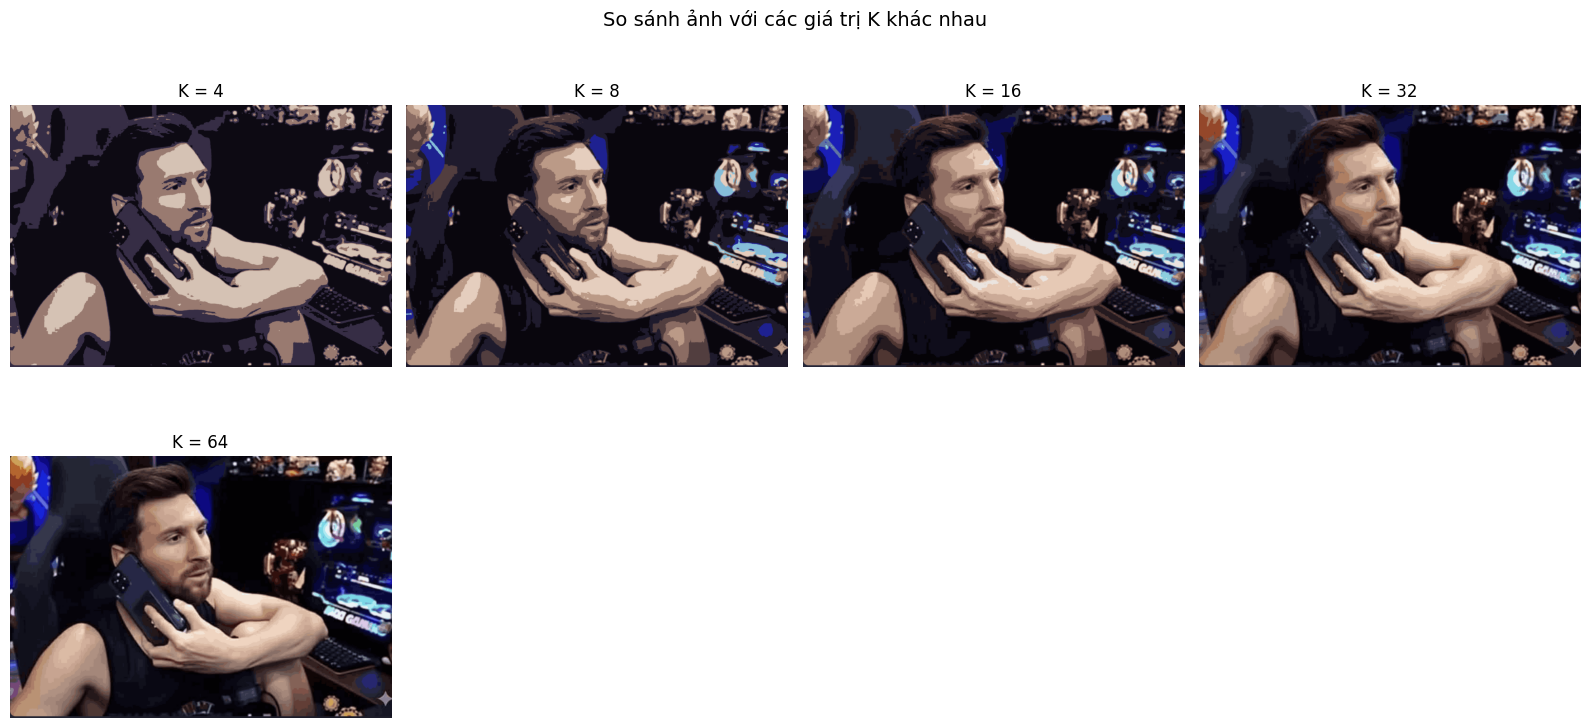

🎨 Xây dựng palette với K=16 để minh họa


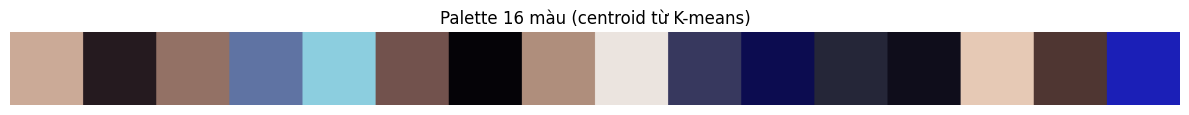

🔍 Đang tìm K tối ưu (target: 50.00 KB)...
  Thử K=129 →  414.92 KB (diff: 364.92 KB)
  Thử K= 65 →  330.53 KB (diff: 280.53 KB)
  Thử K= 33 →  232.36 KB (diff: 182.36 KB)
  Thử K= 17 →  175.51 KB (diff: 125.51 KB)
  Thử K=  9 →  127.23 KB (diff: 77.23 KB)
  Thử K=  5 →   95.71 KB (diff: 45.71 KB)
  Thử K=  2 →   27.51 KB (diff: 22.49 KB)
  Thử K=  3 →   52.50 KB (diff: 2.50 KB)
  Thử K=  4 →   73.82 KB (diff: 23.82 KB)

✅ K tối ưu tìm được (ước lượng): 3
   Dung lượng ước lượng gần target: 52.50 KB



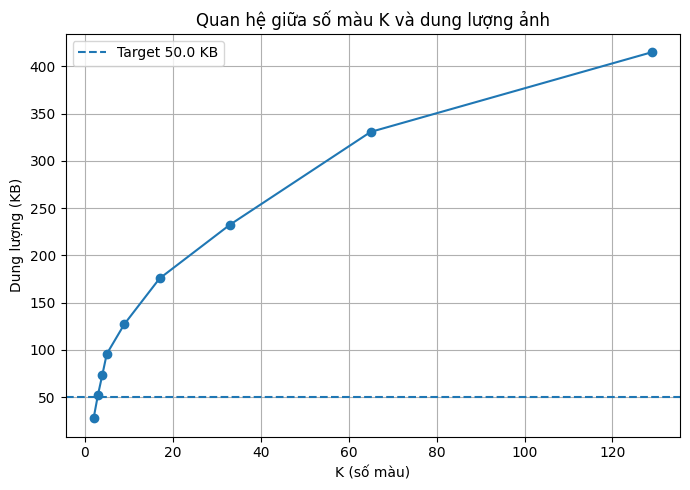

🖼️ Tạo ảnh cuối cùng với K=3 và lưu file...
💾 Ảnh sau nén lưu tại: output_quantized.png
📉 Dung lượng ảnh sau nén (PNG-8): 52.50 KB
⚖️ Tỷ lệ nén: 97.7% so với ảnh gốc



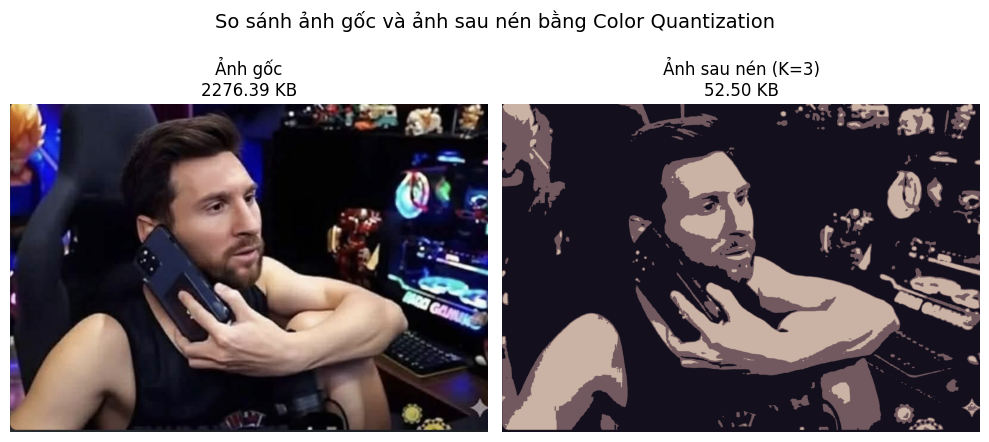

In [8]:
# %% ENTRY POINT

if __name__ == "__main__":
    # 👉 Bạn chỉnh lại đường dẫn ảnh & target_kb ở đây cho phù hợp
    INPUT_IMAGE = "input.png"   # Đổi thành ảnh của bạn
    TARGET_KB = 50.0                # Ví dụ muốn nén xuống ~50 KB

    demo_pipeline(INPUT_IMAGE, TARGET_KB)

In [9]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os

def visualize_image_loading(path: str):
    # 1. Mở ảnh gốc
    if not os.path.exists(path):
        raise FileNotFoundError(f"File không tồn tại: {path}")
    
    img_raw = Image.open(path)
    mode_before = img_raw.mode

    # 2. Chuẩn hóa về RGB
    if img_raw.mode != "RGB":
        img_rgb = img_raw.convert("RGB")
    else:
        img_rgb = img_raw

    # 3. Chuyển sang numpy array
    arr = np.array(img_rgb)
    h, w, c = arr.shape
    dtype = arr.dtype

    print("🔍 THÔNG TIN ẢNH SAU KHI ĐỌC")
    print(f"- Đường dẫn: {path}")
    print(f"- Mode ban đầu: {mode_before}")
    print(f"- Mode sau chuẩn hóa: {img_rgb.mode}")
    print(f"- Kích thước (W x H): {w} x {h}")
    print(f"- Shape numpy: {arr.shape}")
    print(f"- Kiểu dữ liệu: {dtype}")

    # 4. Visualize: ảnh gốc + ảnh sau chuẩn hóa + info
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    # Ảnh gốc
    axes[0].imshow(img_raw if mode_before != "L" else img_raw.convert("RGB"))
    axes[0].set_title(f"Ảnh gốc\nmode = {mode_before}")
    axes[0].axis("off")

    # Ảnh sau chuẩn hóa RGB
    axes[1].imshow(img_rgb)
    axes[1].set_title(f"Sau chuẩn hóa\nmode = {img_rgb.mode}")
    axes[1].axis("off")

    # Thông tin dạng text
    info_text = (
        f"Thông tin sau khi đọc:\n"
        f"- Mode ban đầu: {mode_before}\n"
        f"- Mode sau: {img_rgb.mode}\n"
        f"- Kích thước: {w} x {h}\n"
        f"- Shape numpy: {arr.shape}\n"
        f"- dtype: {dtype}"
    )
    axes[2].text(0.01, 0.5, info_text, fontsize=11, va="center")
    axes[2].axis("off")

    plt.suptitle("Bước 1: Đọc ảnh từ tệp & Chuẩn hóa dữ liệu", fontsize=14)
    plt.tight_layout()
    plt.show()

    return arr

🔍 THÔNG TIN ẢNH SAU KHI ĐỌC
- Đường dẫn: input.png
- Mode ban đầu: RGBA
- Mode sau chuẩn hóa: RGB
- Kích thước (W x H): 2618 x 1798
- Shape numpy: (1798, 2618, 3)
- Kiểu dữ liệu: uint8


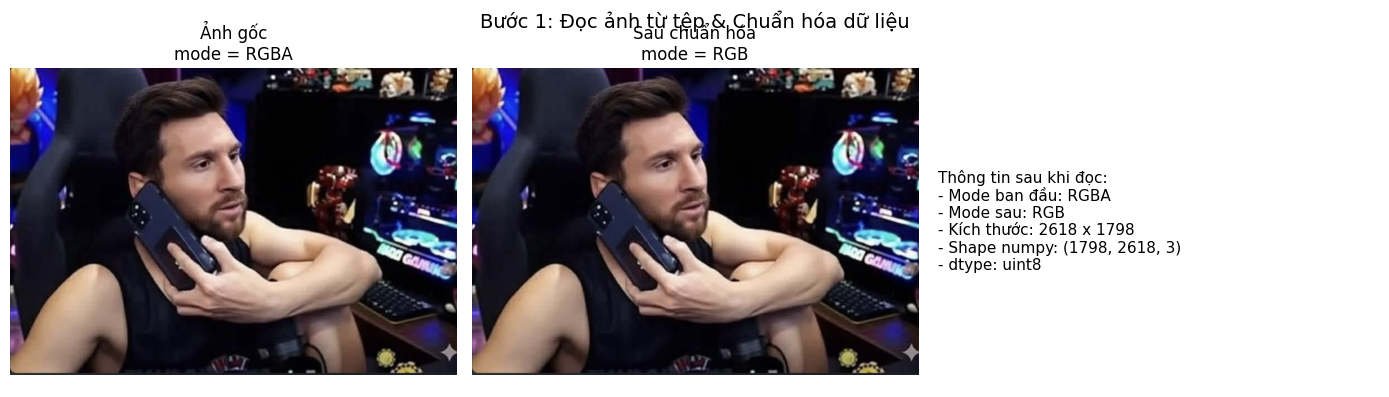

In [11]:
if __name__ == "__main__":
    arr = visualize_image_loading("input.png")
    # sau đó mới dùng arr cho K-means

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def visualize_array_processing(path: str):
    # 1. Đọc ảnh gốc
    img_raw = Image.open(path)
    print("Mode ban đầu:", img_raw.mode)

    # 2. Chuẩn hóa về RGB
    img_rgb = img_raw.convert("RGB")
    arr = np.array(img_rgb)

    print("Mode sau chuẩn hóa:", img_rgb.mode)
    print("Shape numpy:", arr.shape)
    print("dtype:", arr.dtype)

    # 3. In 1 phần array (để người xem thấy ảnh là ma trận số)
    print("\n5 pixel đầu tiên (reshape -1,3):")
    print(arr.reshape(-1, 3)[:5])

    # 4. Hiển thị ảnh & array dạng trực quan
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    # Ảnh gốc
    axes[0].imshow(img_raw if img_raw.mode=="RGB" else img_raw.convert("RGB"))
    axes[0].set_title(f"Ảnh gốc\nmode={img_raw.mode}")
    axes[0].axis("off")

    # Ảnh RGB chuẩn hóa
    axes[1].imshow(img_rgb)
    axes[1].set_title("Ảnh sau chuẩn hóa (RGB)")
    axes[1].axis("off")

    # Hiển thị pixel dạng lưới nhỏ (giúp nhìn rõ giá trị)
    small = arr[:20, :20]            # lấy 20x20 pixel đầu
    axes[2].imshow(small)
    axes[2].set_title("20×20 pixel đầu")
    axes[2].axis("off")

    # Heatmap 1 kênh (cho thấy pixel là số)
    axes[3].imshow(arr[:80, :80, 0], cmap="gray")
    axes[3].set_title("Kênh R (heatmap)")
    axes[3].axis("off")

    plt.suptitle("Biểu diễn quá trình xử lý ảnh → NumPy Array", fontsize=14)
    plt.tight_layout()
    plt.show()

    return arr

Mode ban đầu: RGBA
Mode sau chuẩn hóa: RGB
Shape numpy: (1798, 2618, 3)
dtype: uint8

5 pixel đầu tiên (reshape -1,3):
[[62 56 55]
 [62 56 55]
 [62 56 55]
 [62 56 55]
 [62 56 55]]


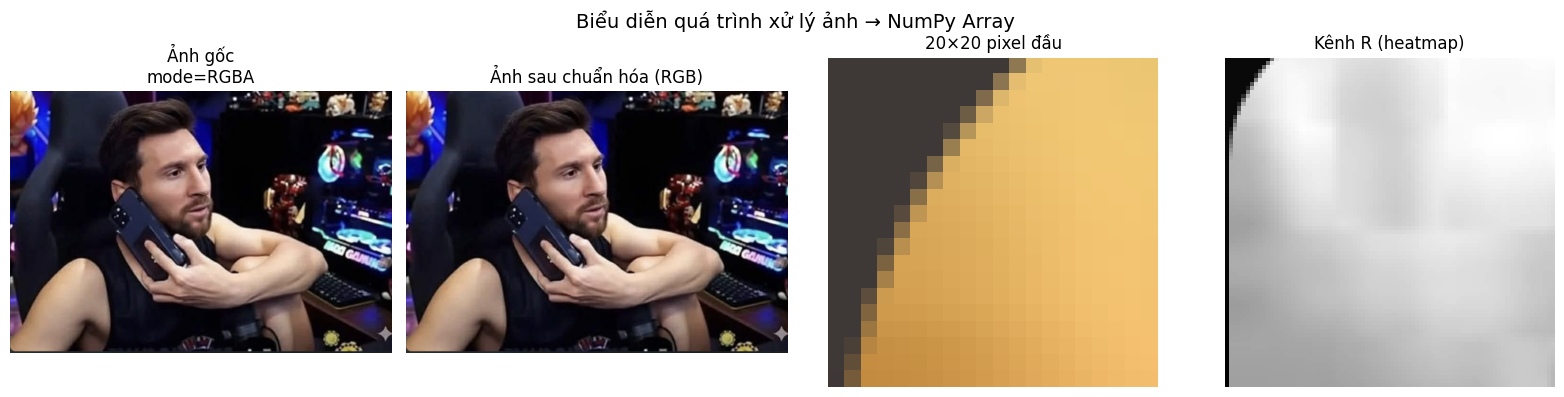

In [21]:
arr = visualize_array_processing("input.png")